# 🤖 Treinamento — Classificador de Gestos
**Entrada:** `dataset_gestos.csv` gerado pelo coletor  
**Modelos comparados:** Random Forest, SVM, MLP (Rede Neural)  
**Saída:** Acurácia de cada modelo no conjunto de teste

## 📦 1. Instalação das dependências
```bash
uv add pandas scikit-learn matplotlib
```

In [16]:
# Descomente se precisar instalar no ambiente do notebook
# !pip install pandas scikit-learn matplotlib -q

## 📚 2. Importações

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")

## ⚙️ 2. Configurações

In [18]:
# ── Caminho do CSV gerado pelo coletor ────────────────────────────────────────
CSV_PATH = "dataset_gestos.csv"

# ── Proporção do conjunto de teste (0.0 – 1.0) ────────────────────────────────
TEST_SIZE = 0.2

# ── Semente para reprodutibilidade ───────────────────────────────────────────
RANDOM_STATE = 42

# ── Folds para validação cruzada ─────────────────────────────────────────────
CV_FOLDS = 2

print("Configurações carregadas.")

Configurações carregadas.


## 📂 3. Carregamento e Preparação dos Dados

In [19]:
df = pd.read_csv(CSV_PATH)

print(f"Total de amostras : {len(df)}")
print(f"Features          : {len(df.columns) - 1}")
print(f"\nDistribuição por label:")
print(df["label"].value_counts().to_string())

# Separar features e target
X = df.drop(columns=["label"]).values
y = df["label"].values

# Codificar labels em inteiros
le = LabelEncoder()
y  = le.fit_transform(y)

print(f"\nClasses: {list(le.classes_)}")

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"\nTreino : {len(X_train)} amostras")
print(f"Teste  : {len(X_test)} amostras")

Total de amostras : 124
Features          : 63

Distribuição por label:
label
thumbs_up    46
rock         40
hang_lose    38

Classes: ['hang_lose', 'rock', 'thumbs_up']

Treino : 99 amostras
Teste  : 25 amostras


## 🤖 4. Definição dos Modelos

Cada modelo é encapsulado em um `Pipeline` com `StandardScaler` para garantir comparação justa.

In [20]:
modelos = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=RANDOM_STATE,
        )),
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            random_state=RANDOM_STATE,
        )),
    ]),

    "MLP (Rede Neural)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            max_iter=500,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print(f"{len(modelos)} modelos definidos.")

3 modelos definidos.


## 🏋️ 5. Treinamento e Avaliação

In [21]:
resultados = []

for nome, pipeline in modelos.items():
    print(f"Treinando {nome}...", end=" ")

    # Validação cruzada no conjunto de treino
    n_splits = min(CV_FOLDS, len(X_train))
    scores_cv = cross_val_score(
    pipeline, X_train, y_train,
    cv=n_splits, scoring="accuracy"
)

    # Treina no conjunto completo de treino e avalia no teste
    pipeline.fit(X_train, y_train)
    acc_teste = pipeline.score(X_test, y_test)

    resultados.append({
        "Modelo"       : nome,
        "CV médio"     : scores_cv.mean(),
        "CV desvio"    : scores_cv.std(),
        "Acurácia Teste": acc_teste,
    })

    print(f"CV: {scores_cv.mean():.1%} ± {scores_cv.std():.1%}  |  Teste: {acc_teste:.1%}")

df_resultados = pd.DataFrame(resultados).sort_values("Acurácia Teste", ascending=False)
print("\n✅ Treinamento concluído!")
df_resultados

Treinando Random Forest... CV: 82.8% ± 1.2%  |  Teste: 100.0%
Treinando SVM... CV: 85.9% ± 1.9%  |  Teste: 100.0%
Treinando MLP (Rede Neural)... CV: 80.8% ± 0.8%  |  Teste: 100.0%

✅ Treinamento concluído!


,Modelo,CV médio,CV desvio,Acurácia Teste
0,Random Forest,0.828163,0.011837,1.0
1,SVM,0.858776,0.018776,1.0
2,MLP (Rede Neural),0.808163,0.008163,1.0


## 📊 6. Comparação Visual

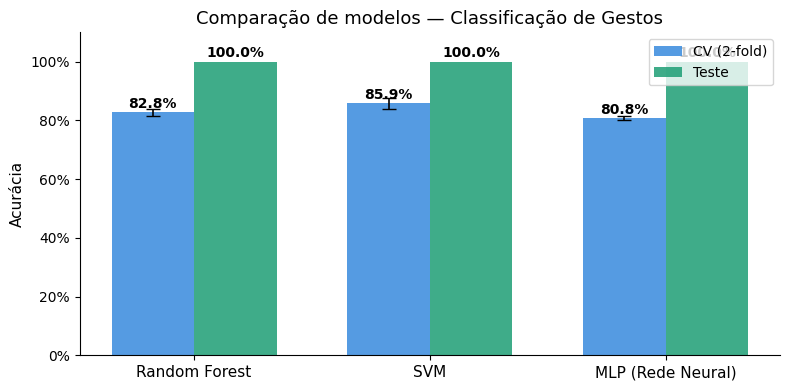

Gráfico salvo em: comparacao_modelos.png


In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

nomes   = df_resultados["Modelo"].tolist()
acc_cv  = df_resultados["CV médio"].tolist()
acc_te  = df_resultados["Acurácia Teste"].tolist()
desvios = df_resultados["CV desvio"].tolist()

x      = np.arange(len(nomes))
largura = 0.35

barras_cv = ax.bar(x - largura / 2, acc_cv, largura,
                   label=f"CV ({CV_FOLDS}-fold)",
                   color="#378ADD", alpha=0.85,
                   yerr=desvios, capsize=5, error_kw={"elinewidth": 1.2})

barras_te = ax.bar(x + largura / 2, acc_te, largura,
                   label="Teste",
                   color="#1D9E75", alpha=0.85)

# Rótulos de valor em cima de cada barra
for bar in list(barras_cv) + list(barras_te):
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.005,
        f"{altura:.1%}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylabel("Acurácia", fontsize=11)
ax.set_title("Comparação de modelos — Classificação de Gestos", fontsize=13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("comparacao_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em: comparacao_modelos.png")

## 🏆 7. Melhor Modelo

In [23]:
melhor = df_resultados.iloc[0]
print(f"🏆 Melhor modelo  : {melhor['Modelo']}")
print(f"   Acurácia teste : {melhor['Acurácia Teste']:.1%}")
print(f"   CV médio       : {melhor['CV médio']:.1%} ± {melhor['CV desvio']:.1%}")

🏆 Melhor modelo  : Random Forest
   Acurácia teste : 100.0%
   CV médio       : 82.8% ± 1.2%
